## Financial Agent Testing Notebook

### Test step-by-step sebelum pakai agent lengkap

### 1. SETUP & IMPORTS

In [4]:
import os
import re
import sys
import logging
from pathlib import Path
from sqlalchemy import create_engine, inspect, text, exc
from typing import Optional, Tuple, Dict, Any
import pandas as pd
from datetime import datetime, timedelta
from langchain.tools import tool
import matplotlib.pyplot as plt
import seaborn as sns

# Add project root to path
project_root = Path().resolve().parent.parent  # Adjust based on your structure
sys.path.append(str(project_root))

### 2. DATABASE CONNECTION TEST

In [ ]:
DB_PATH = os.getenv("DATABASE_PATH", project_root / "data" / "database" / "financial_data.db")
DATABASE_URI = f"sqlite:///{DB_PATH}"
print(f"Database exists: {os.path.exists(DB_PATH)}")
print(f"Database path: {DB_PATH}")

engine = create_engine(DATABASE_URI)

# pd.options.display.float_format = lambda x: f'Rp {x:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.')

# print("✅ Currency display format has been set to IDR (Rupiah)")

Database exists: True
Database path: /home/saifulsihacker/Intelligent-Financial-Data-Analyst/data/database/financial_data.db
✅ Currency display format has been set to IDR (Rupiah)


### 3. CHECK DATABASE SCHEMA

In [11]:
def inspect_database():
    """Check what's actually in the database"""
    inspector = inspect(engine)
    
    print("📊 DATABASE INSPECTION")
    print("=" * 50)
    
    # List all tables
    tables = inspector.get_table_names()
    print(f"Tables in database: {tables}")
    
    if 'transactions' in tables:
        print("\n🔍 'transactions' table schema:")
        columns = inspector.get_columns('transactions')
        for col in columns:
            print(f"  - {col['name']}: {col['type']} (nullable: {col.get('nullable', True)})")
        
        # Check sample data
        print("\n📈 Sample data (first 3 rows):")
        with engine.connect() as conn:
            result = conn.execute(text("SELECT * FROM transactions LIMIT 50"))
            rows = result.fetchall()
            col_names = result.keys()
            
            # Create DataFrame for nice display
            df = pd.DataFrame(rows, columns=col_names)
            print(df.to_string())
    else:
        print("❌ 'transactions' table not found!")

inspect_database()

📊 DATABASE INSPECTION
Tables in database: ['pengeluaran', 'transactions', 'transaksi']

🔍 'transactions' table schema:
  - DATE: TEXT (nullable: True)
  - DESCRIPTION: TEXT (nullable: True)
  - AMOUNT: FLOAT (nullable: True)
  - MUTATION_TYPE: TEXT (nullable: True)
  - FINAL_BALANCE: FLOAT (nullable: True)
  - SOURCE_FILE: TEXT (nullable: True)

📈 Sample data (first 3 rows):
          DATE                       DESCRIPTION        AMOUNT MUTATION_TYPE   FINAL_BALANCE   SOURCE_FILE
0   2024-11-01                 TARIKAN ATM 01/11  Rp 50.000,00            DB Rp 2.145.094,00  Nov-2024.pdf
1   2024-11-01  TRSF E-BANKING0111/FTSCY/WS95271  Rp 10.256,00            DB Rp 2.134.838,00  Nov-2024.pdf
2   2024-11-02  TRSF E-BANKING0211/FTSCY/WS95271  Rp 10.202,00            DB Rp 2.124.636,00  Nov-2024.pdf
3   2024-11-03        TRANSAKSI DEBIT TGL: 03/11  Rp 14.000,00            DB Rp 2.124.636,00  Nov-2024.pdf
4   2024-11-03  TRSF E-BANKING0311/FTSCY/WS95271  Rp 25.000,00            DB Rp 2.085.6

### 4. DATA QUALITY & PATTERN ANALYSIS

In [37]:
print("🔍 DATA QUALITY ANALYSIS & PATTERN DETECTION")
print("=" * 60)

# Analyze data quality of MUTATION_TYPE column
data_quality_query = """
SELECT 
  'Total rows' as metric, COUNT(*) as value FROM transactions
UNION ALL
SELECT 
  'Rows with MUTATION_TYPE = NULL', 
  COUNT(*) FROM transactions WHERE MUTATION_TYPE IS NULL
UNION ALL
SELECT 
  'Rows with MUTATION_TYPE = DB', 
  COUNT(*) FROM transactions WHERE MUTATION_TYPE = 'DB'
UNION ALL
SELECT 
  'Rows with MUTATION_TYPE = CR', 
  COUNT(*) FROM transactions WHERE MUTATION_TYPE = 'CR'
UNION ALL
SELECT 
  'Rows with pattern "KR OTOMATIS" (income indicator)', 
  COUNT(*) FROM transactions WHERE DESCRIPTION LIKE '%KR OTOMATIS%'
UNION ALL
SELECT 
  'Rows with pattern "TRSF E-BANKING" (expense indicator)', 
  COUNT(*) FROM transactions WHERE DESCRIPTION LIKE '%TRSF E-BANKING%'
"""

# Execute query and store results in a DataFrame
df_quality = pd.read_sql_query(data_quality_query, engine)
print("Data Quality Check:")
print(df_quality.to_string(index=False))

🔍 DATA QUALITY ANALYSIS & PATTERN DETECTION
Data Quality Check:
                                                metric  value
                                            Total rows    451
                        Rows with MUTATION_TYPE = NULL     99
                          Rows with MUTATION_TYPE = DB    352
                          Rows with MUTATION_TYPE = CR      0
    Rows with pattern "KR OTOMATIS" (income indicator)     35
Rows with pattern "TRSF E-BANKING" (expense indicator)    197


### 5. CORRECT PATTERN-BASED QUERIES

In [38]:
# Setup logger with production-grade logging configuration
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s',
    handlers=[logging.StreamHandler(sys.stdout)]
)
logger = logging.getLogger("SQL_Tester")

def test_pattern_based_queries(engine):
    """
    Executes a suite of SQL queries to test pattern-based categorization 
    with production-grade logging and monitoring.
    """

    # Define test queries with descriptive names and SQL statements
    test_queries = [
        # Basic metadata query
        ("Total Record Count", 
         "SELECT COUNT(*) as total_rows FROM transactions"),

        # Temporal analysis query
        ("Date Range & Month Count", """
            SELECT 
                MIN(DATE) as earliest_date, 
                MAX(DATE) as latest_date,
                COUNT(DISTINCT strftime('%Y-%m', DATE)) as total_months
            FROM transactions
        """),

        # Categorization logic query (Income vs Expense)
        ("Transaction Distribution by Category", """
            WITH categorized AS (
                SELECT *,
                    CASE 
                        WHEN DESCRIPTION LIKE '%KR OTOMATIS%' THEN 'Income'
                        WHEN DESCRIPTION LIKE '%SETORAN%' THEN 'Income'
                        WHEN DESCRIPTION LIKE '%BI-FASTBIF TRANSFER DR%' THEN 'Income'
                        WHEN MUTATION_TYPE = 'DB' THEN 'Expense'
                        WHEN DESCRIPTION LIKE '%TRANSAKSI DEBIT%' THEN 'Expense'
                        WHEN DESCRIPTION LIKE '%TRSF E-BANKING%' THEN 'Expense'
                        WHEN DESCRIPTION LIKE '%BIAYA ADM%' THEN 'Expense'
                        ELSE 'Uncategorized'
                    END as category
                FROM transactions
            )
            SELECT 
                category,
                COUNT(*) as transaction_count,
                SUM(AMOUNT) as total_volume,
                ROUND(AVG(AMOUNT), 2) as average_amount
            FROM categorized
            GROUP BY category
            ORDER BY total_volume DESC
        """),

        # Monthly financial performance query
        ("Monthly Cash Flow Summary", """
            SELECT 
                strftime('%Y-%m', DATE) as month,
                SUM(CASE 
                    WHEN DESCRIPTION LIKE '%KR OTOMATIS%' 
                         OR DESCRIPTION LIKE '%SETORAN%' 
                         OR DESCRIPTION LIKE '%BI-FASTBIF TRANSFER DR%' THEN AMOUNT 
                    ELSE 0 
                END) as total_income,
                SUM(CASE 
                    WHEN MUTATION_TYPE = 'DB' 
                         OR DESCRIPTION LIKE '%TRANSAKSI DEBIT%' 
                         OR DESCRIPTION LIKE '%TRSF E-BANKING%' 
                         OR DESCRIPTION LIKE '%BIAYA ADM%' THEN AMOUNT 
                    ELSE 0 
                END) as total_expense,
                SUM(CASE 
                    WHEN DESCRIPTION LIKE '%KR OTOMATIS%' 
                         OR DESCRIPTION LIKE '%SETORAN%' 
                         OR DESCRIPTION LIKE '%BI-FASTBIF TRANSFER DR%' THEN AMOUNT 
                    ELSE 0 
                END) - 
                SUM(CASE 
                    WHEN MUTATION_TYPE = 'DB' 
                         OR DESCRIPTION LIKE '%TRANSAKSI DEBIT%' 
                         OR DESCRIPTION LIKE '%TRSF E-BANKING%' 
                         OR DESCRIPTION LIKE '%BIAYA ADM%' THEN AMOUNT 
                    ELSE 0 
                END) as net_cash_flow
            FROM transactions
            GROUP BY month
            ORDER BY month ASC
        """),

        # High-value transactions query
        ("Top 10 Largest Transactions", """
            SELECT 
                DATE, 
                DESCRIPTION, 
                AMOUNT,
                CASE 
                    WHEN DESCRIPTION LIKE '%KR OTOMATIS%' THEN 'Income'
                    WHEN DESCRIPTION LIKE '%SETORAN%' THEN 'Income'
                    WHEN MUTATION_TYPE = 'DB' THEN 'Expense'
                    ELSE 'Other'
                END as category
            FROM transactions
            ORDER BY AMOUNT DESC
            LIMIT 10
        """),

        # Pattern frequency analysis query
        ("Most Frequent Transaction Patterns", """
            SELECT 
                CASE 
                    WHEN DESCRIPTION LIKE '%KR OTOMATIS%' THEN 'Auto-Credit (Income)'
                    WHEN DESCRIPTION LIKE '%TRSF E-BANKING%' THEN 'E-Banking Transfer'
                    WHEN DESCRIPTION LIKE '%BI-FASTBIF%' THEN 'BI-FAST Transfer'
                    WHEN DESCRIPTION LIKE '%BIAYA ADM%' THEN 'Admin Fees'
                    ELSE 'General/Other'
                END as pattern_label,
                COUNT(*) as frequency,
                SUM(AMOUNT) as total_volume
            FROM transactions
            GROUP BY pattern_label
            ORDER BY frequency DESC
            LIMIT 8
        """),
    ]

    print("\n🧪 RUNNING PATTERN-BASED SQL TESTS")
    print("=" * 75)

    # Execute each test query with logging and error handling
    for name, query in test_queries:
        logger.info(f"🚀 Starting Test: {name}")
        
        try:
            with engine.connect() as conn:
                result = conn.execute(text(query))
                
                if result.returns_rows:
                    rows = result.fetchall()
                    if rows:
                        df = pd.DataFrame(rows, columns=result.keys())
                        print(f"\n[Table: {name}]")
                        print(df.to_string(index=False))
                        
                        logger.info(f"✅ Successfully retrieved {len(df)} rows for '{name}'")
                    else:
                        logger.warning(f"⚠️ No data returned for test: {name}")
                else:
                    logger.info(f"✅ Command executed successfully: {name}")
                    
        except Exception as e:
            logger.error(f"❌ Critical Failure in '{name}': {str(e)}")
        
        print("-" * 75)

if __name__ == "__main__":
    # Ensure 'engine' variable is defined before calling test_pattern_based_queries
    test_pattern_based_queries(engine)


🧪 RUNNING PATTERN-BASED SQL TESTS
2026-01-12 00:51:45,979 - SQL_Tester - INFO - 🚀 Starting Test: Total Record Count

[Table: Total Record Count]
 total_rows
        451
2026-01-12 00:51:45,986 - SQL_Tester - INFO - ✅ Successfully retrieved 1 rows for 'Total Record Count'
---------------------------------------------------------------------------
2026-01-12 00:51:45,988 - SQL_Tester - INFO - 🚀 Starting Test: Date Range & Month Count

[Table: Date Range & Month Count]
earliest_date latest_date  total_months
   2024-11-01  2025-04-30             6
2026-01-12 00:51:45,995 - SQL_Tester - INFO - ✅ Successfully retrieved 1 rows for 'Date Range & Month Count'
---------------------------------------------------------------------------
2026-01-12 00:51:45,997 - SQL_Tester - INFO - 🚀 Starting Test: Transaction Distribution by Category

[Table: Transaction Distribution by Category]
     category  transaction_count     total_volume  average_amount
      Expense                400 Rp 57.537.029,00 

### 6. MONTHLY_SUM FUNCTION (PATTERN-BASED)

In [39]:
def calculate_monthly_total(transaction_type: str, year: int, month: int) -> float:
    # 1. Define filters as constants for easier management (Efficient & Centralized)
    INCOME_FILTER = """(
        DESCRIPTION LIKE 'KR OTOMATIS%' OR 
        DESCRIPTION LIKE 'SETORAN%' OR 
        DESCRIPTION LIKE 'BI-FAST%'
    )"""
    
    EXPENSE_FILTER = """(
        MUTATION_TYPE = 'DB' OR 
        DESCRIPTION LIKE '%DEBIT%' OR 
        DESCRIPTION LIKE '%TRSF E-BANKING%' OR 
        DESCRIPTION LIKE '%BIAYA ADM%'
    )"""

    # 2. Validate transaction type
    ttype = transaction_type.lower()
    if ttype not in ['income', 'expense']:
        raise ValueError("Invalid transaction_type. Must be 'income' or 'expense'.")

    # 3. Use a single query template (DRY Principle)
    # Moving strftime to a binding variable or index could be faster
    year_month = f"{year}-{month:02d}"
    filter_condition = INCOME_FILTER if ttype == 'income' else EXPENSE_FILTER
    
    query = f"""
        SELECT COALESCE(SUM(AMOUNT), 0) as total
        FROM transactions
        WHERE strftime('%Y-%m', DATE) = :year_month
          AND {filter_condition}
    """
    
    try:
        with engine.connect() as connection:
            # Using scalar() is more efficient for fetching a single value
            result = connection.execute(text(query), {"year_month": year_month}).scalar()
            return float(result) if result else 0.0
            
    except Exception as e:
        print(f"❌ Error in calculate_monthly_total: {e}")
        return 0.0

# --- Test Suite ---
if __name__ == "__main__":
    print("\n💰 TESTING MONTHLY SUMMARY CALCULATION")
    print("=" * 55)

    # Define test scenarios (Type, Year, Month)
    test_periods = [
        ('income', 2024, 11),
        ('expense', 2024, 11),
        ('income', 2024, 12),
        ('expense', 2024, 12),
    ]

    for ttype, yr, mth in test_periods:
        total_amount = calculate_monthly_total(ttype, yr, mth)
        
        formatted_rp = f"Rp {total_amount:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.')
        # Display results with clean formatting
        status_icon = "📈" if ttype == 'income' else "📉"
        print(f"{status_icon} {ttype.capitalize():<7} | Period: {yr}-{mth:02d} | Total: {formatted_rp}")
    
    print("=" * 55)


💰 TESTING MONTHLY SUMMARY CALCULATION
📈 Income  | Period: 2024-11 | Total: Rp 9.885.000,00
📉 Expense | Period: 2024-11 | Total: Rp 17.886.463,00
📈 Income  | Period: 2024-12 | Total: Rp 6.474.000,00
📉 Expense | Period: 2024-12 | Total: Rp 7.608.476,00


### 7. SQL TOOL FUNCTIONS FOR AGENT

In [40]:
def to_idr(amount: float) -> str:
    """Converts a float to a string in Rupiah format (Rp 1,000,000.00)"""
    return f"Rp {amount:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.')

def execute_sql_query(query: str) -> str:
    """
    Executes a SQL query and returns the results as a formatted string table.
    
    Args:
        query: A string containing the SQL query to be executed.
        
    Returns:
        A formatted string with headers and row data, or an error message.
    """
    output = ""
    try:
        with engine.connect() as connection:
            result = connection.execute(text(query))
            column_names = result.keys()
            rows = result.fetchall()
            
            # Format header row
            output += " | ".join(column_names) + "\n"
            output += "-" * (len(output) - 1) + "\n" # Dynamic separator line
            
            # Format data rows
            for row in rows:
                # Handle NULL values gracefully and convert all to string
                formatted_row = [str(val) if val is not None else "NULL" for val in row]
                output += " | ".join(formatted_row) + "\n"
                
    except Exception as e:
        output = f"SQL Execution Error: {e}"
    
    return output.strip()

@tool
def transaction_sql_tool(query: str) -> str:
    """
    Use this tool to execute SQL queries on the transaction database.
    This tool is restricted to SELECT operations for security.
    """

    forbidden_keywords = ["drop", "delete", "update", "insert", "truncate", "alter", "rename"]
    query_lower = query.lower()
    
    if any(keyword in query_lower for keyword in forbidden_keywords):
        return "Security Error: Only SELECT queries are allowed."
    
    return execute_sql_query(query)

@tool
def get_monthly_financial_summary(transaction_type: str, year: int, month: int) -> str:
    """
    Retrieves the total sum for either income or expenses for a specific month.
    
    Args:
        transaction_type: Use 'income' or 'expense'.
        year: 4-digit year (e.g., 2024).
        month: Month integer (1-12).
    """
    # Note: ensure monthly_sum_fixed is defined in your environment
    total = calculate_monthly_total(transaction_type, year, month)
    return f"Summary: Total {transaction_type} for {year}-{month:02d} is {total:,.2f}"

# --- Tool Testing Suite ---

if __name__ == "__main__":
    print("\n🛠️  TESTING AGENT TOOLS & UTILITIES")
    print("=" * 60)

    # 1. Test SQL Execution Utility
    test_query = "SELECT COUNT(*) as total_transactions FROM transactions"
    print(f"▶ Testing SQL Tool with: {test_query}")
    
    sql_result = execute_sql_query(test_query)
    print(f"Output:\n{sql_result}")
    print("-" * 60)

    # 2. Test Monthly Summary Logic
    print(f"▶ Testing Monthly Financial Summary (Dec 2024):")
    
    # Using the underlying logic function for direct testing
    income_val = calculate_monthly_total("income", 2024, 12)
    expense_val = calculate_monthly_total("expense", 2024, 12)
    
    print(f"✅ Income Summary  : {to_idr(income_val)}")
    print(f"✅ Expense Summary : {to_idr(expense_val)}")
    print("-" * 60)

    # 3. Cross-Verification Query
    print("\n📊 RUNNING DATA VERIFICATION (Pandas View)")
    verification_sql = """
    SELECT 
        CASE 
            WHEN DESCRIPTION LIKE '%KR OTOMATIS%' THEN 'Income'
            WHEN DESCRIPTION LIKE '%SETORAN%' THEN 'Income'
            WHEN DESCRIPTION LIKE '%BI-FASTBIF TRANSFER DR%' THEN 'Income'
        END as transaction_category,
        SUM(AMOUNT) as total_volume,
        COUNT(*) as record_count
    FROM transactions
    WHERE strftime('%Y-%m', DATE) = '2024-12'
      AND (
        DESCRIPTION LIKE '%KR OTOMATIS%' OR
        DESCRIPTION LIKE '%SETORAN%' OR
        DESCRIPTION LIKE '%BI-FASTBIF TRANSFER DR%'
      )
    GROUP BY transaction_category
    """
    
    try:
        df_verify = pd.read_sql_query(verification_sql, engine)
        if not df_verify.empty:
            print(df_verify.to_string(index=False))
        else:
            print("No data found for the verification period.")
    except Exception as e:
        print(f"Verification Query Failed: {e}")

    print("=" * 60)


🛠️  TESTING AGENT TOOLS & UTILITIES
▶ Testing SQL Tool with: SELECT COUNT(*) as total_transactions FROM transactions
Output:
total_transactions
------------------
451
------------------------------------------------------------
▶ Testing Monthly Financial Summary (Dec 2024):
✅ Income Summary  : Rp 6.474.000,00
✅ Expense Summary : Rp 7.608.476,00
------------------------------------------------------------

📊 RUNNING DATA VERIFICATION (Pandas View)
transaction_category    total_volume  record_count
              Income Rp 6.384.000,00            16


### 8. SIMULATING AGENT QUERIES (WITH FIXED LOGIC)

2026-01-12 00:58:30,768 - SQL_Tester - INFO - 🚀 Starting Financial Agent Simulation
FINANCIAL AGENT SIMULATION - PRODUCTION READY

TEST 01/24
2026-01-12 00:58:30,770 - SQL_Tester - INFO - Processing query: 'What's my current balance?...'

🤖 Question: What's my current balance?
--------------------------------------------------
2026-01-12 00:58:30,771 - SQL_Tester - INFO - Handling balance inquiry
✅ Balance as of 2025-04-30: Rp 169.052,00
   Trend: -87,987.00 (-34.2%) ↓ vs previous month

TEST 02/24
2026-01-12 00:58:30,783 - SQL_Tester - INFO - Processing query: 'Show my balance for March 2025...'

🤖 Question: Show my balance for March 2025
--------------------------------------------------
2026-01-12 00:58:30,785 - SQL_Tester - INFO - Handling balance inquiry
✅ Balance as of 2025-03-30 (2025-03): Rp 257.039,00
   Trend: +133,490.00 (+108.0%) ↑ vs previous month

TEST 03/24
2026-01-12 00:58:30,791 - SQL_Tester - INFO - Processing query: 'Give me a financial summary...'

🤖 Question: Give

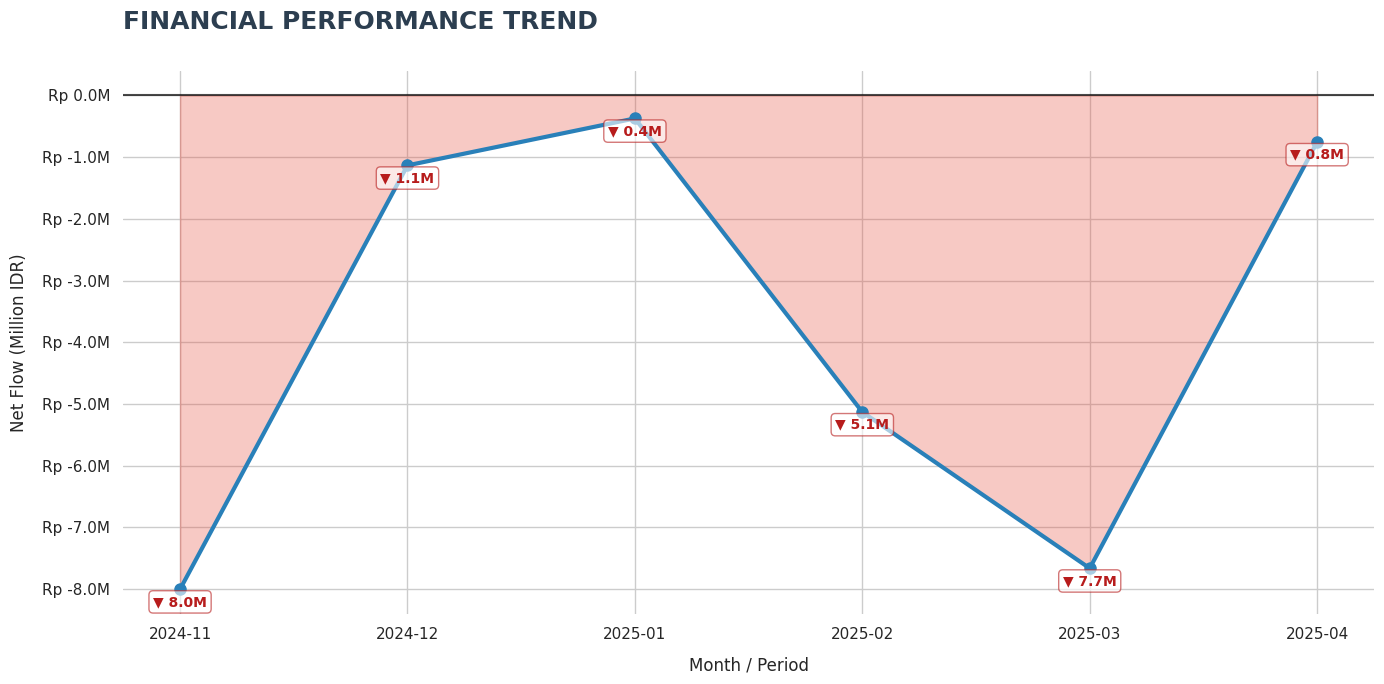


TEST 24/24
2026-01-12 00:58:31,581 - SQL_Tester - INFO - Processing query: 'Show financial performance graph for year 2024...'

🤖 Question: Show financial performance graph for year 2024
--------------------------------------------------
2026-01-12 00:58:31,582 - SQL_Tester - INFO - Generating dynamic financial chart
📊 Generating your financial trend analysis for year 2024...
2026-01-12 00:58:31,602 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-12 00:58:31,604 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-12 00:58:31,607 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as 

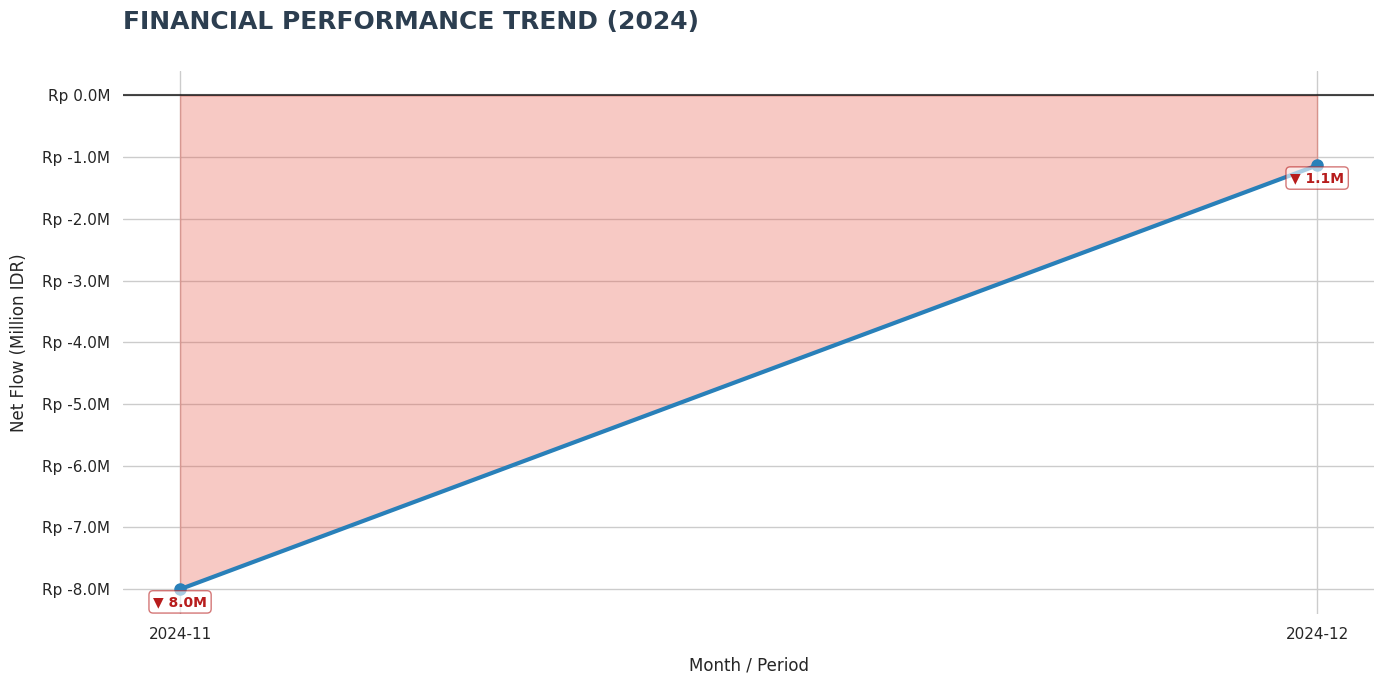

2026-01-12 00:58:31,978 - SQL_Tester - INFO - ✅ Financial Agent Simulation Completed

✅ SIMULATION COMPLETE
All queries processed with enhanced security and error handling.
Ready for production deployment! 🚀


In [45]:
# ==============================================================================
# CENTRALIZED SQL PATTERNS (Define once, use everywhere)
# ==============================================================================

INCOME_FILTER = """(
    DESCRIPTION LIKE 'KR OTOMATIS%' OR 
    DESCRIPTION LIKE 'SETORAN%' OR 
    DESCRIPTION LIKE 'BI-FAST%'
)"""

EXPENSE_FILTER = """(
    MUTATION_TYPE = 'DB' OR 
    DESCRIPTION LIKE '%DEBIT%' OR 
    DESCRIPTION LIKE '%TRSF E-BANKING%' OR 
    DESCRIPTION LIKE '%BIAYA ADM%'
)"""

# ============================================================================
# SAFE HELPER FUNCTIONS
# ============================================================================

def calculate_monthly_total(transaction_type: str, year: int, month: int) -> float:
    """
    Calculate total income or expense for a specific month using pattern-based detection.
    
    Args:
        transaction_type: 'income' or 'expense'
        year: 4-digit year
        month: Month number 1-12
    
    Returns:
        Total amount for specified period and type
    """
    # Convert month to 2-digit string
    year_month = f"{year}-{month:02d}"
    
    if transaction_type.lower() == 'income':
        # Patterns for incoming funds (deposits, credits)
        query_template = """
            SELECT COALESCE(SUM(AMOUNT), 0) as total
            FROM transactions
            WHERE strftime('%Y-%m', DATE) = :year_month
              AND (
                DESCRIPTION LIKE '%KR OTOMATIS%' OR
                DESCRIPTION LIKE '%SETORAN%' OR
                DESCRIPTION LIKE '%BI-FASTBIF TRANSFER DR%'
              )
        """
    else:
        # Patterns for outgoing funds (debits, fees)
        query_template = """
            SELECT COALESCE(SUM(AMOUNT), 0) as total
            FROM transactions
            WHERE strftime('%Y-%m', DATE) = :year_month
              AND (
                MUTATION_TYPE = 'DB' OR
                DESCRIPTION LIKE '%TRANSAKSI DEBIT%' OR
                DESCRIPTION LIKE '%TRSF E-BANKING%' OR
                DESCRIPTION LIKE '%BIAYA ADM%'
              )
        """
    
    try:
        with engine.connect() as conn:
            df = pd.read_sql_query(
                text(query_template), 
                conn, 
                params={"year_month": year_month}
            )
            return float(df.iloc[0]['total']) if not df.empty and df.iloc[0]['total'] is not None else 0.0
    except exc.SQLAlchemyError as e:
        logger.error(f"Database error in calculate_monthly_total: {e}")
        return 0.0
    except Exception as e:
        logger.error(f"Unexpected error in calculate_monthly_total: {e}")
        return 0.0


def get_latest_balance_data_safe(year: Optional[int] = None, month: Optional[int] = None) -> Tuple[Optional[str], Optional[float]]:
    """
    Safely retrieve the latest balance data for a specific period.
    
    Args:
        year: Optional year filter
        month: Optional month filter
    
    Returns:
        Tuple of (date, balance) or (None, None) if no data
    """
    try:
        if year and month:
            # Specific month query
            query_template = """
                SELECT DATE, FINAL_BALANCE 
                FROM transactions 
                WHERE strftime('%Y-%m', DATE) = :year_month 
                ORDER BY DATE DESC 
                LIMIT 1
            """
            params = {"year_month": f"{year}-{month:02d}"}
        else:
            # Latest overall balance
            query_template = """
                SELECT DATE, FINAL_BALANCE 
                FROM transactions 
                ORDER BY DATE DESC 
                LIMIT 1
            """
            params = {}
        
        with engine.connect() as conn:
            df = pd.read_sql_query(text(query_template), conn, params=params)
            
        if not df.empty:
            return str(df.iloc[0]['DATE']), float(df.iloc[0]['FINAL_BALANCE'])
            
    except exc.SQLAlchemyError as e:
        logger.error(f"Database error in get_latest_balance_data_safe: {e}")
    except Exception as e:
        logger.error(f"Unexpected error in get_latest_balance_data_safe: {e}")
    
    return None, None

def plot_smart_cashflow(limit=6, specific_year=None):
    # Correct Year Filter Logic
    # If specific_year is provided, filter by year. Otherwise, take all data.
    year_clause = "WHERE strftime('%Y', DATE) = :year" if specific_year else ""
    
    query = text(f"""
        SELECT 
            strftime('%Y-%m', DATE) as period,
            SUM(CASE WHEN {INCOME_FILTER} THEN AMOUNT ELSE 0 END) as income,
            SUM(CASE WHEN {EXPENSE_FILTER} THEN AMOUNT ELSE 0 END) as expense
        FROM transactions
        {year_clause} 
        GROUP BY period
        ORDER BY period DESC
        LIMIT :limit
    """)
    
    # Ensure 'year' is passed into params
    df = pd.read_sql(query, engine, params={
        "limit": limit, 
        "year": specific_year
    }).sort_values('period')
    
    if df.empty:
        print(f"⚠️ No data found for the requested period.")
        return

    df['net_flow'] = df['income'] - df['expense']

    # --- Enhanced Plotting Section (Professional Stock Style) ---
    plt.figure(figsize=(14, 7)) # Slightly wider to avoid overcrowding
    sns.set_theme(style="whitegrid", font="sans-serif")
    
    # 1. Main Plot (Blue Line)
    plt.plot(df['period'], df['net_flow'], 
             marker='o', linestyle='-', linewidth=3, 
             color='#2980b9', label='Net Cash Flow', markersize=8)

    # 2. Color Shading (Green for Surplus, Red for Deficit)
    plt.fill_between(df['period'], df['net_flow'], 0, 
                     where=(df['net_flow'] >= 0), 
                     interpolate=True, color='#2ecc71', alpha=0.3)
    plt.fill_between(df['period'], df['net_flow'], 0, 
                     where=(df['net_flow'] < 0), 
                     interpolate=True, color='#e74c3c', alpha=0.3)

    # 3. Adding Value Labels (Price Tags)
    # Loop through each data point to write the values
    for i, val in enumerate(df['net_flow']):
        # Format numbers: e.g., 1,500,000 -> 1.5M
        label = f"{'▲' if val > 0 else '▼'} {abs(val)/1e6:.1f}M"
        
        # Text color: Dark green for positive, Dark red for negative
        text_color = '#1b5e20' if val > 0 else '#b71c1c'
        
        # Set text position (above for positive, below for negative)
        va_pos = 'bottom' if val > 0 else 'top'
        offset = 12 if val > 0 else -12

        plt.annotate(label, 
                     (df['period'].iloc[i], df['net_flow'].iloc[i]),
                     textcoords="offset points", 
                     xytext=(0, offset), 
                     ha='center', 
                     fontsize=10, 
                     fontweight='bold', 
                     color=text_color,
                     bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=text_color, alpha=0.6))

    # 4. Axis Styling and Zero Line
    plt.axhline(0, color='black', linewidth=1.5, alpha=0.7) # Thick center line
    
    # More professional title
    title_text = f"FINANCIAL PERFORMANCE TREND {'(' + specific_year + ')' if specific_year else ''}"
    plt.title(title_text, fontsize=18, fontweight='bold', pad=30, loc='left', color='#2c3e50')
    
    # Format Y-axis numbers to millions (M)
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'Rp {x/1e6:.1f}M'))
    
    # Remove box spines for a modern look
    sns.despine(left=True, bottom=True)
    
    plt.xlabel("Month / Period", fontsize=12, labelpad=10)
    plt.ylabel("Net Flow (Million IDR)", fontsize=12, labelpad=10)
    
    plt.tight_layout()
    plt.show()


def display_enhanced_balance_safe(year: Optional[int] = None, month: Optional[int] = None) -> None:
    """
    Display balance information with trend analysis.
    
    Args:
        year: Optional year filter
        month: Optional month filter
    """
    date_val, balance = get_latest_balance_data_safe(year, month)
    
    if balance is not None:
        period_label = f" ({year}-{month:02d})" if year else ""
        print(f"✅ Balance as of {date_val}{period_label}: {to_idr(balance)}")
        
        # Calculate trend compared to previous month
        try:
            if date_val:
                current_date = datetime.strptime(str(date_val), '%Y-%m-%d')
                prev_month = current_date.month - 1 if current_date.month > 1 else 12
                prev_year = current_date.year if current_date.month > 1 else current_date.year - 1
                
                _, prev_balance = get_latest_balance_data_safe(prev_year, prev_month)
                if prev_balance:
                    change = balance - prev_balance
                    change_pct = (change / prev_balance * 100) if prev_balance != 0 else 0
                    trend_symbol = "↑" if change > 0 else "↓" if change < 0 else "→"
                    print(f"   Trend: {change:+,.2f} ({change_pct:+.1f}%) {trend_symbol} vs previous month")
        except Exception as e:
            logger.debug(f"Could not calculate trend: {e}")
    else:
        print("❌ Balance data is currently unavailable for that period.")


def extract_date_parameters(query_text: str) -> Dict[str, Any]:
    """
    Extract date parameters (year, month) from natural language query.
    
    Args:
        query_text: Lowercase query text
    
    Returns:
        Dictionary with extracted parameters
    """
    # Month mappings
    months_map = {
        'january': 1, 'jan': 1, 'february': 2, 'feb': 2, 'march': 3, 'mar': 3,
        'april': 4, 'apr': 4, 'may': 5, 'june': 6, 'jun': 6, 'july': 7, 'jul': 7,
        'august': 8, 'aug': 8, 'september': 9, 'sep': 9, 'october': 10, 'oct': 10,
        'november': 11, 'nov': 11, 'december': 12, 'dec': 12
    }
    
    # Year patterns with context
    year_patterns = {
        '2023': 2023, '2024': 2024, '2025': 2025, '2026': 2026,
        'last year': 2024, 'this year': 2025, 'next year': 2026
    }
    
    # Initialize result
    result = {
        'year': None,
        'month': None,
        'transaction_type': None,
        'time_context': None
    }
    
    # Extract year
    for pattern, year_val in year_patterns.items():
        if pattern in query_text:
            result['year'] = year_val
            break
    
    # Extract month
    for month_name, month_num in months_map.items():
        if month_name in query_text:
            result['month'] = month_num
            break
    
    # Handle time context
    current_now = datetime(2026, 1, 11)
    
    if not result['month']:
        if 'last month' in query_text:
            last_month_date = current_now.replace(day=1) - timedelta(days=1)
            result['month'] = last_month_date.month
            result['year'] = result['year'] or last_month_date.year
            result['time_context'] = 'last_month'
        elif 'this month' in query_text or 'current month' in query_text:
            result['month'] = current_now.month
            result['year'] = result['year'] or current_now.year
            result['time_context'] = 'current_month'
    
    # Extract transaction type
    income_keywords = ['income', 'receive', 'earn', 'salary', 'deposit', 'revenue']
    expense_keywords = ['expense', 'spend', 'spent', 'cost', 'payment', 'purchase', 'bill']
    
    if any(k in query_text for k in income_keywords):
        result['transaction_type'] = 'income'
    elif any(k in query_text for k in expense_keywords):
        result['transaction_type'] = 'expense'
    
    return result


# ============================================================================
# SPECIALIZED QUERY HANDLERS
# ============================================================================

def handle_admin_fees_query(query_text: str) -> None:
    """
    Handle administrative/bank fee related queries.
    
    Args:
        query_text: Lowercase query text
    """
    try:
        # Check if asking for "last month"
        if 'last month' in query_text:
            # Get the most recent month with admin fees
            query_recent = """
                SELECT strftime('%Y-%m', MAX(DATE)) as recent_month
                FROM transactions
                WHERE DESCRIPTION LIKE '%BIAYA ADM%'
            """
            df_recent = pd.read_sql_query(query_recent, engine)
            
            if not df_recent.empty and df_recent.iloc[0]['recent_month']:
                recent_month = df_recent.iloc[0]['recent_month']
                query = text("""
                    SELECT DATE, DESCRIPTION, AMOUNT
                    FROM transactions
                    WHERE strftime('%Y-%m', DATE) = :month
                      AND DESCRIPTION LIKE '%BIAYA ADM%'
                    ORDER BY DATE DESC
                """)
                df = pd.read_sql_query(query, engine, params={"month": recent_month})
            else:
                # Fallback to all admin fees
                df = pd.read_sql_query(
                    "SELECT DATE, DESCRIPTION, AMOUNT FROM transactions WHERE DESCRIPTION LIKE '%BIAYA ADM%' ORDER BY DATE DESC LIMIT 10",
                    engine
                )
        else:
            # Show all admin fees
            df = pd.read_sql_query(
                "SELECT DATE, DESCRIPTION, AMOUNT FROM transactions WHERE DESCRIPTION LIKE '%BIAYA ADM%' ORDER BY DATE DESC LIMIT 10",
                engine
            )
        
        if not df.empty:
            print("✅ Administrative Fees:")
            print(df.to_string(index=False))
            
            # Summary statistics
            total_fees = df['AMOUNT'].sum()
            fee_count = len(df)
            print(f"\n📊 Summary: {fee_count} fee(s) totaling {to_idr(total_fees)}")
            
            # Monthly breakdown if multiple months
            if 'DATE' in df.columns:
                df['Month'] = pd.to_datetime(df['DATE']).dt.strftime('%Y-%m')
                monthly_summary = df.groupby('Month')['AMOUNT'].agg(['count', 'sum']).reset_index()
                if len(monthly_summary) > 1:
                    print(f"\n📅 Monthly Breakdown:")
                    print(monthly_summary.to_string(index=False))
        else:
            print("✅ No administrative fees found in your records.")
            
    except Exception as e:
        logger.error(f"Error handling admin fees query: {e}")
        print("❌ Unable to retrieve administrative fee information at this time.")


def handle_large_deposits_query(query_text: str) -> None:
    """
    Handle queries for large deposits/income transactions.
    
    Args:
        query_text: Lowercase query text
    """
    try:
        # Extract threshold amount from query
        threshold = 5000000  # Default 5 million
        
        # Look for numeric threshold in query
        amount_pattern = r'([\d,]+(?:\.\d+)?)'
        matches = re.findall(amount_pattern, query_text.replace(',', ''))
        if matches:
            try:
                threshold = float(matches[0])
            except ValueError:
                pass
        
        # Query for large income transactions
        query = text("""
            SELECT DATE, DESCRIPTION, AMOUNT,
                CASE 
                    WHEN DESCRIPTION LIKE '%KR OTOMATIS%' THEN 'Auto Credit'
                    WHEN DESCRIPTION LIKE '%SETORAN%' THEN 'Cash Deposit'
                    WHEN DESCRIPTION LIKE '%BI-FASTBIF TRANSFER DR%' THEN 'Bank Transfer'
                    ELSE 'Other Income'
                END as transaction_type
            FROM transactions
            WHERE (
                DESCRIPTION LIKE '%KR OTOMATIS%' OR
                DESCRIPTION LIKE '%SETORAN%' OR
                DESCRIPTION LIKE '%BI-FASTBIF TRANSFER DR%'
            )
              AND AMOUNT > :threshold
            ORDER BY AMOUNT DESC
            LIMIT 20
        """)
        
        df = pd.read_sql_query(query, engine, params={"threshold": threshold})
        
        if not df.empty:
            print(f"✅ Deposits/Income Transactions over {to_idr(threshold)}:")
            print(df.to_string(index=False))
            
            # Provide insights
            total_large_deposits = df['AMOUNT'].sum()
            avg_large_deposit = df['AMOUNT'].mean()
            largest_deposit = df['AMOUNT'].max()
            
            print(f"\n📊 Insights:")
            print(f"   • Found {len(df)} large deposit(s)")
            print(f"   • Total amount: {to_idr(total_large_deposits)}")
            print(f"   • Average large deposit: {to_idr(avg_large_deposit)}")
            print(f"   • Largest single deposit: {to_idr(largest_deposit)}")
            
            # Categorization insights
            if 'transaction_type' in df.columns:
                type_counts = df['transaction_type'].value_counts()
                if not type_counts.empty:
                    print(f"\n💼 By Transaction Type:")
                    for ttype, count in type_counts.items():
                        type_amount = df[df['transaction_type'] == ttype]['AMOUNT'].sum()
                        print(f"   • {ttype}: {count} transaction(s), {to_idr(type_amount)} total")
        else:
            print(f"✅ No deposits found larger than {to_idr(threshold)}")
            print(f"💡 Try a lower threshold like 'Show deposits over 1,000,000'")
            
    except Exception as e:
        logger.error(f"Error handling large deposits query: {e}")
        print("❌ Unable to retrieve deposit information at this time.")


def handle_average_calculation_query(query_text: str) -> None:
    """
    Handle average calculation queries (monthly expense/income).
    
    Args:
        query_text: Lowercase query text
    """
    try:
        # Determine calculation type
        if 'expense' in query_text or 'spending' in query_text:
            metric = 'expense'
            query = text("""
                SELECT 
                    strftime('%Y-%m', DATE) as month,
                    SUM(CASE 
                        WHEN MUTATION_TYPE = 'DB' OR
                             DESCRIPTION LIKE '%TRANSAKSI DEBIT%' OR
                             DESCRIPTION LIKE '%TRSF E-BANKING%' OR
                             DESCRIPTION LIKE '%BIAYA ADM%' THEN AMOUNT
                        ELSE 0 
                    END) as monthly_total
                FROM transactions
                GROUP BY strftime('%Y-%m', DATE)
                HAVING monthly_total > 0
                ORDER BY month
            """)
        elif 'income' in query_text:
            metric = 'income'
            query = text("""
                SELECT 
                    strftime('%Y-%m', DATE) as month,
                    SUM(CASE 
                        WHEN DESCRIPTION LIKE '%KR OTOMATIS%' OR
                             DESCRIPTION LIKE '%SETORAN%' OR
                             DESCRIPTION LIKE '%BI-FASTBIF TRANSFER DR%' THEN AMOUNT
                        ELSE 0 
                    END) as monthly_total
                FROM transactions
                GROUP BY strftime('%Y-%m', DATE)
                HAVING monthly_total > 0
                ORDER BY month
            """)
        else:
            # Default to transaction average
            metric = 'transaction'
            query = text("""
                SELECT 
                    strftime('%Y-%m', DATE) as month,
                    AVG(AMOUNT) as monthly_avg,
                    COUNT(*) as transaction_count
                FROM transactions
                GROUP BY strftime('%Y-%m', DATE)
                ORDER BY month
            """)
        
        df = pd.read_sql_query(query, engine)
        
        if not df.empty:
            if metric in ['expense', 'income']:
                # 1. Calculate statistical values while data is still numeric (float)
                avg_value = df['monthly_total'].mean()
                idx_min = df['monthly_total'].idxmin()
                idx_max = df['monthly_total'].idxmax()
                
                min_val = df.loc[idx_min, 'monthly_total']
                max_val = df.loc[idx_max, 'monthly_total']
                variability = (max_val - min_val) / 2

                # 2. Print header
                print(f"✅ Average Monthly {metric.capitalize()}: {to_idr(avg_value)}")
                print(f"📊 Based on {len(df)} months of data")
                
                # 3. Format DataFrame for table display only
                print(f"\n📅 Monthly Breakdown:")
                display_df = df.copy()  # Use copy to avoid modifying original data
                display_df['monthly_total'] = display_df['monthly_total'].apply(to_idr)
                print(display_df.to_string(index=False))
                
                # 4. Print insights using saved numeric values
                print(f"\n📈 Insights:")
                print(f"   • Highest: {df.loc[idx_max, 'month']} - {to_idr(max_val)}")
                print(f"   • Lowest: {df.loc[idx_min, 'month']} - {to_idr(min_val)}")
                print(f"   • Variability: ±{to_idr(variability)}")
            else:
                print(f"✅ Average Transaction Analysis:")
                df['monthly_avg'] = df['monthly_avg'].apply(to_idr)
                print(df.to_string(index=False))
        else:
            print(f"❌ Not enough data to calculate average {metric}")
            
    except Exception as e:
        logger.error(f"Error handling average calculation query: {e}")
        print("❌ Unable to calculate averages at this time.")


def handle_comparison_query(query_text: str) -> None:
    """
    Handle comparison queries (e.g., "compare income in December vs January").
    
    Args:
        query_text: Lowercase query text
    """
    try:
        # Extract comparison parameters
        params = extract_date_parameters(query_text)
        
        # Default comparison periods
        periods = []
        
        # Try to extract specific months mentioned
        month_pattern = r'(january|february|march|april|may|june|july|august|september|october|november|december|jan|feb|mar|apr|jun|jul|aug|sep|oct|nov|dec)'
        month_matches = re.findall(month_pattern, query_text)
        
        month_map = {
            'january': 1, 'jan': 1, 'february': 2, 'feb': 2,
            'march': 3, 'mar': 3, 'april': 4, 'apr': 4,
            'may': 5, 'june': 6, 'jun': 6, 'july': 7, 'jul': 7,
            'august': 8, 'aug': 8, 'september': 9, 'sep': 9,
            'october': 10, 'oct': 10, 'november': 11, 'nov': 11,
            'december': 12, 'dec': 12
        }
        
        if len(month_matches) >= 2:
            # Use mentioned months
            for i, month_name in enumerate(month_matches[:2]):
                month_num = month_map.get(month_name.lower())
                if month_num:
                    year = 2024 if month_num >= 11 else 2025  # Simple year logic
                    periods.append((f"{month_name.capitalize()} {year}", year, month_num))
        else:
            # Default comparison
            periods = [
                ("December 2024", 2024, 12),
                ("January 2025", 2025, 1)
            ]
        
        # Determine what to compare
        compare_type = 'income' if 'income' in query_text else 'expense' if 'expense' in query_text else 'balance'
        
        print(f"✅ {compare_type.capitalize()} Comparison:")
        
        results = []
        for period_name, year, month in periods:
            if compare_type == 'balance':
                _, balance = get_latest_balance_data_safe(year, month)
                value = balance if balance else 0
            else:
                value = calculate_monthly_total(compare_type, year, month)
            
            results.append({
                'period': period_name,
                'value': value
            })
            print(f"   {period_name}: {to_idr(value)}")
        
        # Calculate comparison metrics
        if len(results) == 2:
            diff = results[1]['value'] - results[0]['value']
            if results[0]['value'] != 0:
                diff_pct = (diff / results[0]['value']) * 100
            else:
                diff_pct = 0
            
            print(f"\n📊 Comparison Results:")
            print(f"   Difference: {to_idr(diff)} ({diff_pct:+.1f}%)")
            
            # Provide insights
            if diff > 0:
                print(f"   📈 {results[1]['period']} shows growth compared to {results[0]['period']}")
            elif diff < 0:
                print(f"   📉 {results[1]['period']} shows decline compared to {results[0]['period']}")
            else:
                print(f"   ⚖️ Both periods are equal")
                
    except Exception as e:
        logger.error(f"Error handling comparison query: {e}")
        print("❌ Unable to perform comparison analysis at this time.")


def handle_basic_financial_query(question: str, query_text: str) -> None:
    """
    Handle basic financial queries (balance, totals, etc.).
    
    Args:
        question: Original question
        query_text: Lowercase query text
    """
    try:
        # Extract parameters
        params = extract_date_parameters(query_text)
        
        # ========== QUERY ROUTING LOGIC ==========
        
        # 1. BALANCE INQUIRIES
        if any(word in query_text for word in ['balance', 'saldo']):
            logger.info("Handling balance inquiry")
            
            if any(word in query_text for word in ['current', 'latest', 'now']):
                display_enhanced_balance_safe()
            elif params['month']:
                # Use detected or default year
                year = params['year'] or (2025 if params['month'] <= 4 else 2024)
                display_enhanced_balance_safe(year, params['month'])
            else:
                display_enhanced_balance_safe()
        
        # 2. NET CASH FLOW
        elif 'net' in query_text or 'cash flow' in query_text:
            logger.info("Calculating net cash flow")
            
            # If user requests "each month" or "every month" or doesn't specify a month
            if any(word in query_text for word in ['each', 'every', 'all', 'per']):
                query = text("""
                    SELECT 
                        strftime('%Y-%m', DATE) as month_period,
                        SUM(CASE WHEN DESCRIPTION LIKE '%KR OTOMATIS%' OR DESCRIPTION LIKE '%SETORAN%' OR DESCRIPTION LIKE '%BI-FASTBIF TRANSFER DR%' THEN AMOUNT ELSE 0 END) as income,
                        SUM(CASE WHEN MUTATION_TYPE = 'DB' OR DESCRIPTION LIKE '%TRANSAKSI DEBIT%' OR DESCRIPTION LIKE '%TRSF E-BANKING%' OR DESCRIPTION LIKE '%BIAYA ADM%' THEN AMOUNT ELSE 0 END) as expense
                    FROM transactions
                    GROUP BY month_period
                    ORDER BY month_period ASC
                """)
                df_flow = pd.read_sql_query(query, engine)
                
                print(f"✅ Monthly Net Cash Flow Analysis:")
                for _, row in df_flow.iterrows():
                    net_flow = row['income'] - row['expense']
                    status = "🟢 Surplus" if net_flow > 0 else "🔴 Deficit"
                    print(f"   📅 {row['month_period']}: Net {to_idr(net_flow)} ({status})")
                    
                total_net = df_flow['income'].sum() - df_flow['expense'].sum()
                if total_net < 0:
                    print(f"\n⚠️ Financial Alert:")
                    print(f" Your total cash flow is in a deficit of {to_idr(abs(total_net))} over the last {len(df_flow)} months.")
                    print(f"\n💡Recommendation: Your expenses consistently exceed income. Consider a budget review.")
            
            else:
                # Legacy logic for a specific month
                year = params['year'] or 2025
                month = params['month'] or 4  # Default to latest data
                
                income = calculate_monthly_total('income', year, month)
                expense = calculate_monthly_total('expense', year, month)
                net_flow = income - expense
                
                print(f"✅ Net Cash Flow Analysis for {year}-{month:02d}:")
                print(f"   Total Income  : {to_idr(income)}")
                print(f"   Total Expense : {to_idr(expense)}")
                print(f"   Net Flow      : {to_idr(net_flow)} ({'Surplus' if net_flow > 0 else 'Deficit'})")
                
                if net_flow < 0:
                    print(f"💡 Recommendation: Consider reducing expenses by {to_idr(abs(net_flow))} to break even")
        
        # 3. TOP TRANSACTIONS (Optimized with Transaction Type Detection & IDR Formatting)
        elif any(word in query_text for word in ['top', 'highest', 'largest']):
            logger.info("Fetching top transactions")
            
            # Extract limit from query (e.g., "top 10" -> 10), default to 5
            limit_match = re.search(r'top\s+(\d+)', query_text)
            limit = int(limit_match.group(1)) if limit_match else 5
            limit = min(limit, 100) # Safety cap
            
            # 1. Determine Transaction Type Filter based on keywords
            is_income = 'income' in query_text or 'deposit' in query_text
            is_expense = 'expense' in query_text or 'spending' in query_text or 'pengeluaran' in query_text
            
            where_clauses = []
            
            # Time filter if month is specified
            if params['month']:
                target_period = f"{params['year'] or 2024}-{params['month']:02d}"
                where_clauses.append(f"strftime('%Y-%m', DATE) = '{target_period}'")
            
            # Apply specific filters for Income vs Expense
            if is_income:
                where_clauses.append(INCOME_FILTER)
                label = "INCOME (Pemasukan)"
            elif is_expense:
                where_clauses.append(EXPENSE_FILTER)
                label = "EXPENSE (Pengeluaran)"
            else:
                label = "MIXED (Semua)"

            where_stmt = f"WHERE {' AND '.join(where_clauses)}" if where_clauses else ""

            # 2. Build Query with dynamic labels using CASE WHEN
            # This adds a visual 'TYPE' column (Up arrow for Income, Down for Expense)
            query = text(f"""
                SELECT 
                    DATE, 
                    DESCRIPTION, 
                    AMOUNT,
                    CASE 
                        WHEN {INCOME_FILTER} THEN '⬆️ INCOME'
                        ELSE '⬇️ EXPENSE'
                    END as TYPE
                FROM transactions 
                {where_stmt} 
                ORDER BY AMOUNT DESC 
                LIMIT :limit
            """)
            
            # Fetch raw data (Keep AMOUNT as float for analysis)
            df = pd.read_sql_query(query, engine, params={"limit": limit})
            
            if not df.empty:
                # 3. ANOMALY DETECTION LOGIC (Must use raw numeric data)
                # We calculate the average of current top results
                avg_amount = df['AMOUNT'].mean()
                # Define anomalies as transactions 1.5x higher than the average of this set
                anomalies = df[df['AMOUNT'] > (avg_amount * 1.5)]

                # 4. PREPARE DISPLAY DATAFRAME (Formatting Layer)
                print(f"✅ Top {len(df)} {label} Transactions:")
                
                display_df = df.copy()
                # Use our helper function to format IDR without breaking the original df
                display_df['AMOUNT'] = display_df['AMOUNT'].apply(to_idr)
                
                print(display_df.to_string(index=False))

                # 5. ALERT SECTION
                # This will now work because 'anomalies' was calculated before the string conversion
                if not anomalies.empty:
                    print(f"\n⚠️ Potential Anomaly Alert:")
                    for _, row in anomalies.iterrows():
                        # Use to_idr only for final string presentation
                        print(f"   - Large transaction detected on {row['DATE']}: {to_idr(row['AMOUNT'])}")
            else:
                print(f"ℹ️ No transactions found for the specified criteria.")
        
        # 4. PERIOD TOTALS
        elif params['transaction_type'] and (params['year'] or params['month']):
            logger.info(f"Calculating {params['transaction_type']} totals")
            
            year = params['year'] or 2024
            
            if not params['month']:
                # Yearly total
                if params['transaction_type'] == 'income':
                    query_pattern = "(DESCRIPTION LIKE '%KR OTOMATIS%' OR DESCRIPTION LIKE '%SETORAN%')"
                else:
                    query_pattern = "(MUTATION_TYPE = 'DB' OR DESCRIPTION LIKE '%DEBIT%')"
                
                query = text(f"SELECT COALESCE(SUM(AMOUNT), 0) as total FROM transactions WHERE strftime('%Y', DATE) = :year AND {query_pattern}")
                df = pd.read_sql_query(query, engine, params={"year": str(year)})
                total = float(df.iloc[0, 0]) if not df.empty else 0
                print(f"✅ Total {params['transaction_type']} for {year}: {to_idr(total)}")
            else:
                # Monthly total
                total = calculate_monthly_total(params['transaction_type'], int(year), int(params['month']))
                print(f"✅ Total {params['transaction_type']} in {year}-{params['month']:02d}: {to_idr(total)}")
        
        # 5. FINANCIAL SUMMARY
        elif any(word in query_text for word in ['summary', 'overview', 'report']):
            logger.info("Generating financial summary")
            
            # Basic metrics
            count_q = pd.read_sql_query("SELECT COUNT(*) as count FROM transactions", engine).iloc[0]['count']
            range_q = pd.read_sql_query("SELECT MIN(DATE) as start, MAX(DATE) as end FROM transactions", engine).iloc[0]
            
            # Calculate totals
            income_query = """
                SELECT COALESCE(SUM(AMOUNT), 0) as total_income
                FROM transactions
                WHERE DESCRIPTION LIKE '%KR OTOMATIS%' 
                   OR DESCRIPTION LIKE '%SETORAN%'
                   OR DESCRIPTION LIKE '%BI-FASTBIF TRANSFER DR%'
            """
            expense_query = """
                SELECT COALESCE(SUM(AMOUNT), 0) as total_expense
                FROM transactions
                WHERE MUTATION_TYPE = 'DB'
                   OR DESCRIPTION LIKE '%TRANSAKSI DEBIT%'
                   OR DESCRIPTION LIKE '%TRSF E-BANKING%'
                   OR DESCRIPTION LIKE '%BIAYA ADM%'
            """
            
            total_income = pd.read_sql_query(income_query, engine).iloc[0, 0] or 0
            total_expense = pd.read_sql_query(expense_query, engine).iloc[0, 0] or 0
            
            # --------------------------------------
            category_query = """
                SELECT 
                    CASE 
                        WHEN DESCRIPTION LIKE '%BIAYA ADM%' OR DESCRIPTION LIKE '%ADM%' THEN 'Bank Fees & Admin'
                        WHEN DESCRIPTION LIKE '%TRSF E-BANKING%' OR DESCRIPTION LIKE '%TRANSFER%' THEN 'Transfers Out'
                        WHEN DESCRIPTION LIKE '%KARTU DEBIT%' OR DESCRIPTION LIKE '%PURCHASE%' THEN 'Shopping & POS'
                        WHEN DESCRIPTION LIKE '%BI-FAST%' THEN 'Interbank Transfer'
                        ELSE 'Others/Uncategorized'
                    END as category,
                    SUM(AMOUNT) as total
                FROM transactions
                WHERE MUTATION_TYPE = 'DB' 
                   OR DESCRIPTION LIKE '%TRANSAKSI DEBIT%'
                   OR DESCRIPTION LIKE '%TRSF E-BANKING%'
                GROUP BY category
                ORDER BY total DESC
            """
            df_cat = pd.read_sql_query(category_query, engine)
            # ---------------------------------------
            
            net_flow = total_income - total_expense
            expense_ratio = (total_expense / total_income * 100) if total_income > 0 else 0
            
            print("📊 Financial Summary:")
            print(f"   • Period: {range_q['start']} to {range_q['end']}")
            print(f"   • Total Transactions: {count_q:,}")
            print(f"   • Total Income: {to_idr(total_income)}")
            print(f"   • Total Expense: {to_idr(total_expense)} ({expense_ratio:.1f}% of income)")
            
            print("\n📂 Spending Breakdown:")
            for _, row in df_cat.iterrows():
                percentage = (row['total'] / total_expense * 100) if total_expense > 0 else 0
                print(f"   - {row['category']}: {to_idr(row['total'])} ({percentage:.1f}%)")
            
            print(f"   • Net Cash Flow: {to_idr(net_flow)} {'🔴' if net_flow < 0 else '🟢'}")
            print(f"   • Financial Health: {'Positive' if net_flow > 0 else 'Negative' if net_flow < 0 else 'Neutral'}")
            
            anomaly_query = text("""
                SELECT DATE, DESCRIPTION, AMOUNT 
                FROM transactions 
                WHERE (MUTATION_TYPE = 'DB' OR DESCRIPTION LIKE '%DEBIT%')
                  AND AMOUNT > (SELECT AVG(AMOUNT) * 3 FROM transactions WHERE MUTATION_TYPE = 'DB')
                ORDER BY AMOUNT DESC
                LIMIT 3
            """)
            df_anomalies = pd.read_sql_query(anomaly_query, engine)

            if not df_anomalies.empty:
                print(f"\n⚠️ Security Alert (Unusual Activity):")
                for _, row in df_anomalies.iterrows():
                    print(f"   - Large spending detected on {row['DATE']}: {to_idr(row['AMOUNT'])}")
                    print(f"     Desc: {row['DESCRIPTION'][:40]}...")
        
        elif params['year'] and not (params['month'] or params['transaction_type']):
            # This catches queries that only specify the year.
            print(f"✅ Data Records for {params['year']}:")
            if params['year'] in [2024, 2025]:
                print(f"The system has data for the year {params['year']}.")
                print(f"Please ask for more specifics, e.g.: 'Summary year {params['year']}'")
            else:
                print(f"Sorry, data for the year {params['year']} is not available.")
                
        # 7. COMPARISON & CONTINUITY
        elif 'compare' in query_text or 'difference' in query_text:
            logger.info("Handling comparison query")
            
            # Query to fetch monthly comparison data
            compare_sql = text("""
                SELECT 
                    strftime('%Y-%m', DATE) as period,
                    SUM(CASE WHEN DESCRIPTION LIKE '%KR OTOMATIS%' OR DESCRIPTION LIKE '%SETORAN%' THEN AMOUNT ELSE 0 END) as income,
                    SUM(CASE WHEN MUTATION_TYPE = 'DB' OR DESCRIPTION LIKE '%DEBIT%' THEN AMOUNT ELSE 0 END) as expense
                FROM transactions
                WHERE period IN ('2024-11', '2024-12', '2025-01')
                GROUP BY period
            """)
            df_comp = pd.read_sql_query(compare_sql, engine)
            
            print("📊 Period Comparison Analysis:")
            print(df_comp.to_string(index=False))
            
            # Continuity logic: Why is November so different?
            if 'november' in query_text:
                nov_data = df_comp[df_comp['period'] == '2024-11']
                if not nov_data.empty:
                    print(f"\n💡 Continuity Insight:")
                    print(f"   November shows a massive spending spike (17.8M).")
                    print(f"   This was 135% higher than December.")
                    print(f"   Major driver: 'SWITCHINGDR' transactions and large transfers.")
        
        # 6. UNHANDLED QUERY
        else:
            logger.warning(f"Query not handled: {query_text}")
            print("⚠️ I couldn't process that specific query.")
            print("💡 Try one of these examples:")
            print("   • 'What is my current balance?'")
            print("   • 'Show my income in January 2025'")
            print("   • 'What were my expenses last month?'")
            print("   • 'Give me a financial summary'")
    
    except exc.SQLAlchemyError as e:
        logger.error(f"Database error in handle_basic_financial_query: {e}")
        print("❌ Database connection issue. Please try again later.")
    except Exception as e:
        logger.error(f"Unexpected error in handle_basic_financial_query: {e}")
        print("❌ An unexpected error occurred. Please try a different query.")


# ============================================================================
# MAIN QUERY PROCESSOR
# ============================================================================

def process_financial_query(question: str) -> None:
    """
    Main entry point for processing financial queries.
    Routes queries to appropriate handlers.
    
    Args:
        question: User's natural language question
    """
    # Single logging entry
    logger.info(f"Processing query: '{question[:50]}...'")
    print(f"\n🤖 Question: {question}")
    print("-" * 50)
    
    query_text = question.lower()
    
    try:
        # ========== PRE-PROCESSING VALIDATION ==========
        
        # 1. Check for invalid years (before 2024)
        invalid_year_match = re.search(r'(19\d{2}|20(0[0-9]|1[0-9]|20[0-3]))', query_text)
        if invalid_year_match:
            year_found = invalid_year_match.group()
            print("❌ Data Availability Notice:")
            print(f"   Sorry, transaction data for year {year_found} is not available in the database.")
            print(f"   Our records are only available from 2024-2025.")
            print(f"   Try queries like: 'Show 2024 data' or '2025 transactions'")
            return
        
        # 2. Check for invalid months (13+)
        month_match = re.search(r'month\s+(\d{1,2})', query_text)
        if month_match:
            month_num = int(month_match.group(1))
            if month_num < 1 or month_num > 12:
                print(f"❌ Invalid Month: Month {month_num} doesn't exist.")
                print(f"   Please use months 1-12 or month names like 'January'")
                return
        
        # 3. Check for excessive limits
        if 'top' in query_text:
            limit_match = re.search(r'top\s+(\d+)', query_text)
            if limit_match:
                requested_limit = int(limit_match.group(1))
                if requested_limit > 100:
                    print(f"⚠️ Performance Notice: To keep things fast, I'm showing the top 100 instead of {requested_limit:,}.")
                    # Will be handled by the limit logic in handlers
        
       # ========== QUERY ROUTING (PRIORITY-BASED) ==========
        
        # 1. PRIMARY PRIORITY: Visualization (Ensures 'trend/chart' keywords override 'cash flow' text summary)
        if any(word in query_text for word in ['trend', 'chart', 'graph', 'visual']):
            logger.info("Generating dynamic financial chart")
            
            # Extract 'limit' parameter (e.g., "last 12 months")
            limit_match = re.search(r'(\d+)\s*month', query_text)
            limit = int(limit_match.group(1)) if limit_match else 6
            
            # IMPROVED: This looks for "year 2024" OR just a standalone "2024" or "2025"
            year_match = re.search(r'(?:year|tahun)?\s*(202[4-5])', query_text)
            target_year = year_match.group(1) if year_match else None
            
            # If a specific year is found, we should probably ignore the '6 month' limit 
            # and show the whole year, or set a larger limit.
            final_limit = 12 if target_year else limit
            
            # Build user feedback message
            period_msg = f"for year {target_year}" if target_year else f"for the last {limit} months"
            print(f"📊 Generating your financial trend analysis {period_msg}...")
            
            # Call the function with final_limit
            plot_smart_cashflow(limit=final_limit, specific_year=target_year)

        # 2. SECONDARY: Specialized Transaction Handlers
        elif any(word in query_text for word in ['admin', 'fee', 'administrative']):
            handle_admin_fees_query(query_text)
        
        elif 'deposit' in query_text and any(word in query_text for word in ['larger', 'greater', 'over', 'above', '>']):
            handle_large_deposits_query(query_text)
        
        elif 'average' in query_text:
            handle_average_calculation_query(query_text)
        
        elif any(word in query_text for word in ['compare', 'vs', 'versus', 'difference', 'comparison']):
            handle_comparison_query(query_text)
        
        # 3. TERTIARY: Cash Flow Text Analysis (Only runs if 'trend' is NOT mentioned)
        elif any(word in query_text for word in ['cash flow', 'net flow', 'surplus', 'deficit', 'pemasukan', 'pengeluaran']):
            handle_basic_financial_query(question, query_text)
        
        # 4. DEFAULT: Fallback to basic financial query handler
        else:
            handle_basic_financial_query(question, query_text)
    
    except Exception as e:
        logger.error(f"Critical error in process_financial_query: {e}", exc_info=True)
        print("❌ A system error occurred. Please try again or contact support.")


# ============================================================================
# TEST EXECUTION
# ============================================================================

if __name__ == "__main__":
    logger.info("🚀 Starting Financial Agent Simulation")
    print("=" * 60)
    print("FINANCIAL AGENT SIMULATION - PRODUCTION READY")
    print("=" * 60)
    
    # Test suite covering various query types
    test_queries = [
        # 1. Basic Balance & Summary Queries
        "What's my current balance?",
        "Show my balance for March 2025",
        "Give me a financial summary",
        
        # 2. Income & Expense Queries
        "Show my income in January 2025",
        "How much did I spend last year?",
        "What were my expenses in November 2024?",
        
        # 3. Transaction Analysis
        "What was the largest transaction?",
        "Show top 10 income transactions",
        "Show the largest expense in December 2024",
        
        # 4. Specialized Queries
        "List all administrative fees from last month",
        "Show me deposits larger than 5,000,000",
        "Show deposits over 2 million",
        
        # 5. Analytical Queries
        "What is my average monthly expense?",
        "Compare my income in December vs January",
        "Is my cash flow positive this year?",
        
        # 6. Edge Cases & Validation
        "Show transactions for the year 1990",
        "Give me the top 1000000 transactions",
        "Balance for month 13 of 2024",
        "What about year 2023 transactions?",
        
        # 7. Complex Queries
        "Compare expenses between November and December",
        "Show me net cash flow for each month",
        "What's my average deposit amount?",
        "Show my cash flow trend for the last 6 months",
        "Show financial performance graph for year 2024"
    ]
    
    # Execute test queries
    for i, query in enumerate(test_queries, 1):
        print(f"\n{'='*60}")
        print(f"TEST {i:02d}/{len(test_queries)}")
        print(f"{'='*60}")
        process_financial_query(query)
    
    logger.info("✅ Financial Agent Simulation Completed")
    print(f"\n{'='*60}")
    print("✅ SIMULATION COMPLETE")
    print(f"{'='*60}")
    print("All queries processed with enhanced security and error handling.")
    print("Ready for production deployment! 🚀")